In [1]:
import scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Estilo general de las gráficas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


**CONSTRUCCIÓN Y GRAFICACIÓN DE SEÑALES EN EL TIEMPO:**


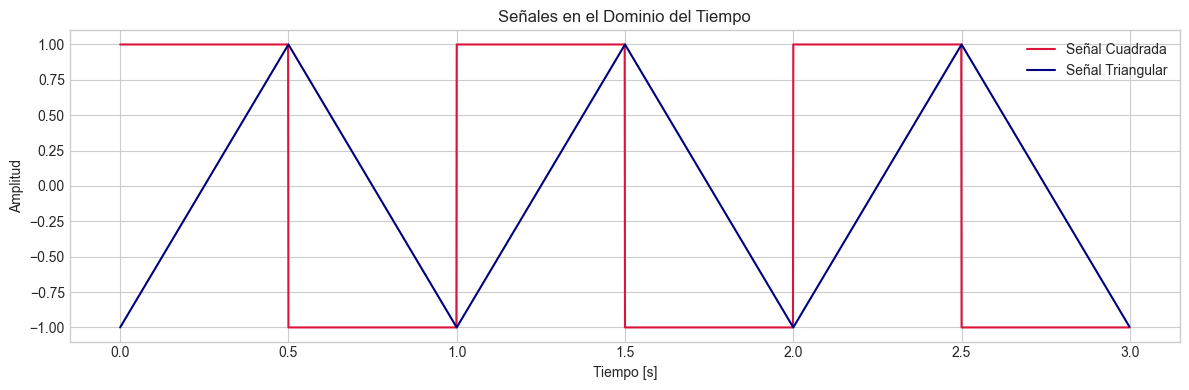

In [ ]:
# Parámetros del sistema
f0 = 1.0           # Frecuencia fundamental (Hz)
T0 = 1.0 / f0      # Período fundamental (s)
A = 1.0            # Amplitud
num_periodos = 3   # Número de períodos a mostrar
N_per_period = 1000 # Muestras por período
N = N_per_period * num_periodos # Total de muestras

# Vector de tiempo
t = np.linspace(0, num_periodos * T0, N, endpoint=False)
dt = t[1] - t[0]

# a) Señal Cuadrada
x_cuadrada = A * signal.square(2 * np.pi * f0 * t)

# b) Señal Triangular (width=0.5 genera simetría triangular)
x_triangular = A * signal.sawtooth(2 * np.pi * f0 * t, width=0.5)

# c) Grafica de ambas señales en el dominio del tiempo
plt.figure(figsize=(12, 4))
plt.plot(t, x_cuadrada, label='Señal Cuadrada', color='crimson', linewidth=1.5)
plt.plot(t, x_triangular, label='Señal Triangular', color='navy', linewidth=1.5)
plt.title('Señales en el Dominio del Tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


**FUNCION PARA OBTENER LOS COEFICIENTES DE LA SERIE DE FOURIER:**

In [3]:
def obtener_coeficientes_fourier(x):
    """
    Calcula los coeficientes complejos c_k de la Serie Exponencial de Fourier
    a partir de una señal x[n] muestreada sobre un período o tramo periódico.
    
    Parámetros:
        x : array_like - Señal de entrada en el tiempo.
        
    Retorna:
        c_k : array_like - Coeficientes de Fourier centrados (fftshift).
        k_harmonics : array_like - Índices de los armónicos correspondientes.
    """
    N_muestras = len(x)
    # FFT normalizada por N para obtener c_k
    c_k_raw = np.fft.fft(x) / N_muestras
    
    # Centrar los armónicos en k = 0
    c_k = np.fft.fftshift(c_k_raw)
    k_harmonics = np.fft.fftshift(np.fft.fftfreq(N_muestras, d=1/N_muestras))
    
    return c_k, k_harmonics


**APLICACIÓN DE LA FUNCIÓN obtener_coefientes_fourier(f) A LAS SEÑALES CUADRADA Y TRIANGULAR:**

In [4]:
c_k_cuadrada, k_cuadrada = obtener_coeficientes_fourier(x_cuadrada)
c_k_triangular, k_triangular = obtener_coeficientes_fourier(x_triangular)


Por el momento, dichos coeficientes se almacenaran en dichas variables solamente, ya que contienen una cantidad considerable de valores que en el siguiente literal se graficaran de forma más clara.

In [12]:
def mostrar_tabla_coeficientes(c_k, k_harmonics, nombre_senal="Señal", max_k=5):
    """
    Imprime una tabla limpia con los coeficientes c_k para los armónicos deseados.
    """
    print(f"=== Coeficientes c_k principales para la {nombre_senal} (k de -{max_k} a +{max_k}) ===")
    print(f"{'k (Armónico)':>12} | {'|c_k| (Magnitud)':>18} | {'Fase (rad)':>12} | {'Fase (grados)':>15}")
    print("-" * 65)
    
    for k_deseado in range(-max_k, max_k + 1):
        # Buscar el índice correspondiente al armónico k_deseado
        idx = np.argmin(np.abs(k_harmonics - k_deseado))
        c = c_k[idx]
        mag = np.abs(c)
        # Limpiar desfases en componentes nulos
        fase_rad = np.angle(c) if mag > 1e-4 else 0.0 
        fase_deg = np.degrees(fase_rad)
        
        print(f"{k_deseado:12d} | {mag:18.4f} | {fase_rad:12.4f} | {fase_deg:15.2f}°")
    print("\n")

# Mostrar los coeficientes de los primeros armónicos (k = -5 a k = +5)
mostrar_tabla_coeficientes(c_k_cuadrada, k_cuadrada, nombre_senal="Señal Cuadrada", max_k=5)
mostrar_tabla_coeficientes(c_k_triangular, k_triangular, nombre_senal="Señal Triangular", max_k=5)

=== Coeficientes c_k principales para la Señal Cuadrada (k de -5 a +5) ===
k (Armónico) |   |c_k| (Magnitud) |   Fase (rad) |   Fase (grados)
-----------------------------------------------------------------
          -5 |             0.0000 |       0.0000 |            0.00°
          -4 |             0.0000 |       0.0000 |            0.00°
          -3 |             0.6366 |       1.5677 |           89.82°
          -2 |             0.0000 |       0.0000 |            0.00°
          -1 |             0.0000 |       0.0000 |            0.00°
           0 |             0.0000 |       0.0000 |            0.00°
           1 |             0.0000 |       0.0000 |            0.00°
           2 |             0.0000 |       0.0000 |            0.00°
           3 |             0.6366 |      -1.5677 |          -89.82°
           4 |             0.0000 |       0.0000 |            0.00°
           5 |             0.0000 |       0.0000 |            0.00°


=== Coeficientes c_k principales para la S

**FUNCION PARA GRAFICAR ESPECTROS DE MAGNITUD Y FASE DE LOS COEFICIENTES DE FOURIER:**

In [5]:
def graficar_espectro(c_k, k_harmonics, titulo="Señal", max_k=25):
    """
    Grafica los espectros de magnitud |c_k| y fase arg(c_k) de una señal.
    """
    # Filtrar el rango de armónicos a visualizar (-max_k a +max_k)
    mask = (k_harmonics >= -max_k) & (k_harmonics <= max_k)
    k_sub = k_harmonics[mask]
    c_k_sub = c_k[mask]
    
    magnitud = np.abs(c_k_sub)
    # Limpiar ruido numérico en la fase para magnitudes muy pequeñas
    fase = np.angle(c_k_sub)
    fase[magnitud < 1e-4] = 0.0  
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    # Espectro de Magnitud
    ax1.stem(k_sub, magnitud, basefmt=" ", linefmt='b-', markerfmt='bo')
    ax1.set_title(f'Espectro de Magnitud $|c_k|$ - {titulo}')
    ax1.set_ylabel('Magnitud')
    ax1.grid(True)
    
    # Espectro de Fase
    ax2.stem(k_sub, fase, basefmt=" ", linefmt='r-', markerfmt='ro')
    ax2.set_title(f'Espectro de Fase $\\arg(c_k)$ [rad] - {titulo}')
    ax2.set_xlabel('Orden del Armónico ($k$)')
    ax2.set_ylabel('Fase [rad]')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


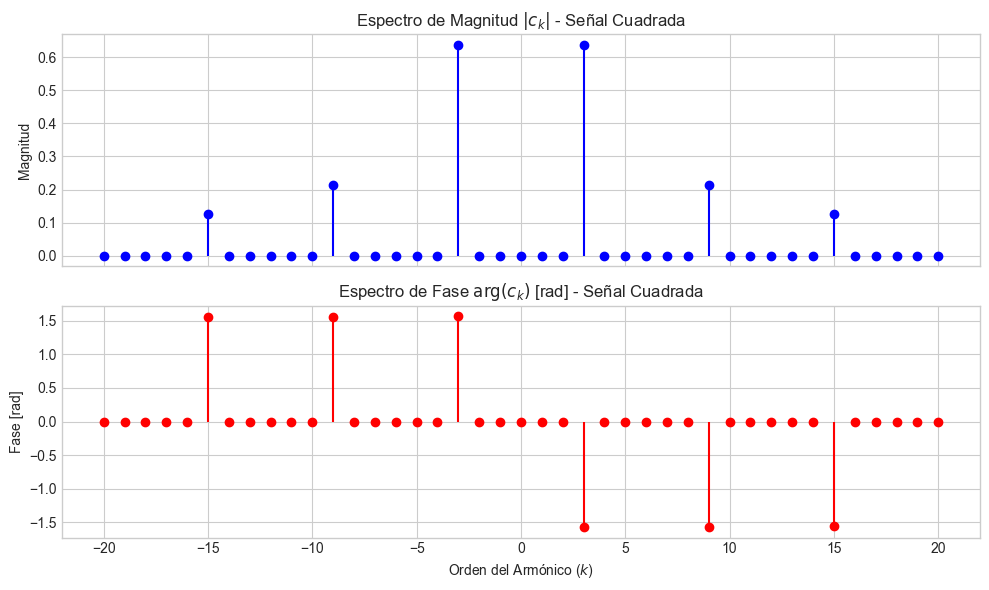

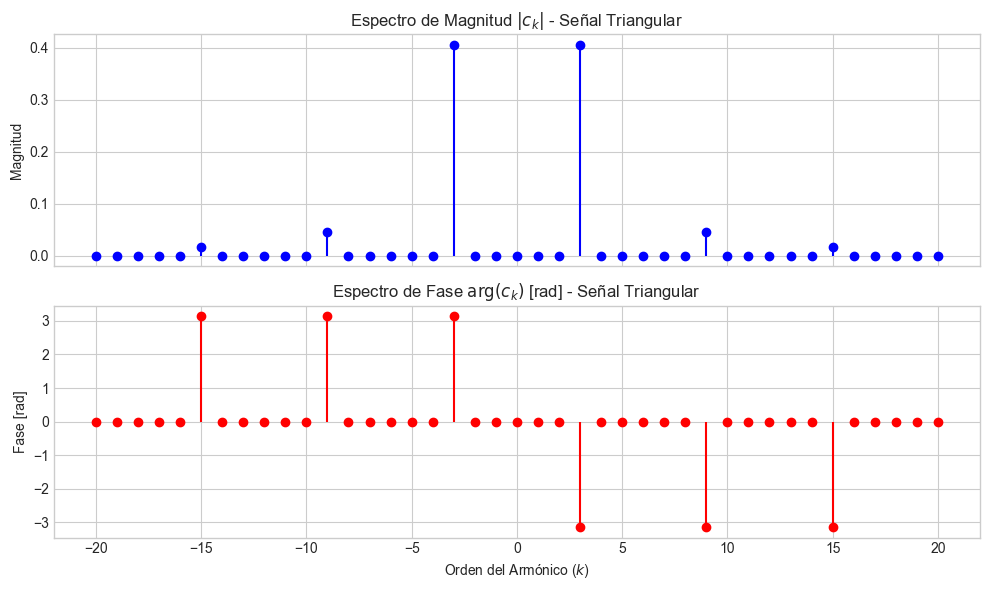

In [6]:
# g) Graficar espectros de ambas señales
graficar_espectro(c_k_cuadrada, k_cuadrada, titulo="Señal Cuadrada", max_k=20)
graficar_espectro(c_k_triangular, k_triangular, titulo="Señal Triangular", max_k=20)


**FUNCION PARA LA RECONSTRUCCIÓN PROGRESIVA DE LA SEÑAL CON SUS RESPECTIVAS GRAFICAS:**

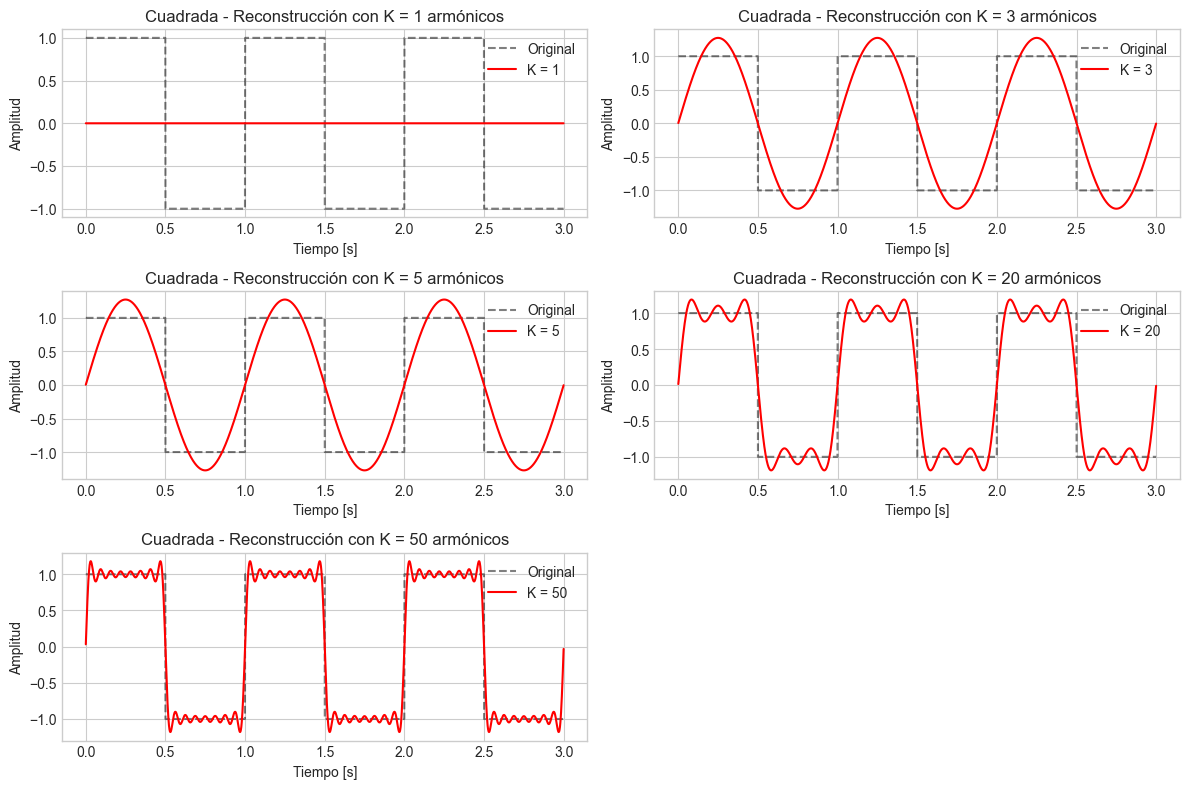

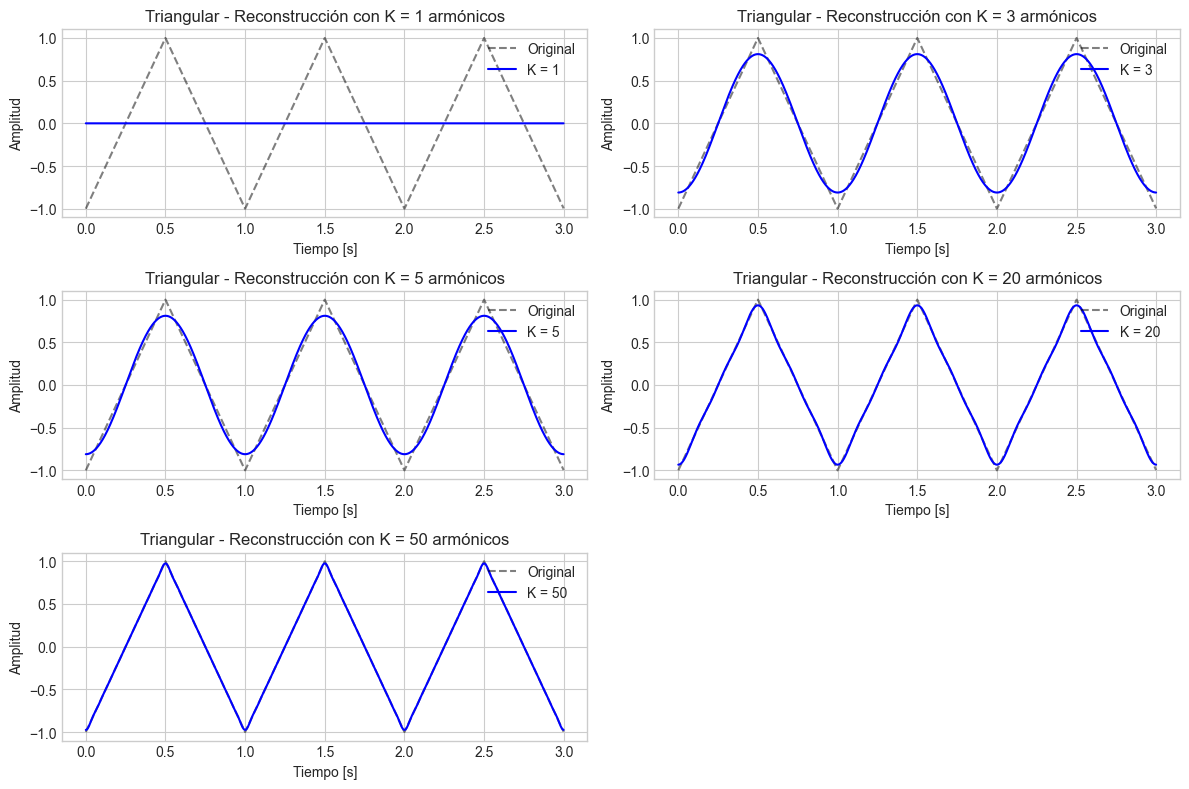

In [7]:
def reconstruir_senal(c_k, k_harmonics, K_armonicos):
    """
    Reconstruye la señal en el dominio del tiempo utilizando únicamente 
    armónicos en el rango [-K_armonicos, K_armonicos].
    """
    # Copiar coeficientes y enmascarar los armónicos de orden mayor a K
    c_k_filtrado = c_k.copy()
    c_k_filtrado[np.abs(k_harmonics) > K_armonicos] = 0.0
    
    # Deshacer el fftshift y aplicar IFFT multiplicando por N (para compensar la división inicial)
    c_k_ishifted = np.fft.ifftshift(c_k_filtrado)
    x_reconstruida = np.real(np.fft.ifft(c_k_ishifted) * len(c_k))
    
    return x_reconstruida

# i) Reconstruir con K = 1, 3, 5, 20, 50
armonicos = [1, 3, 5, 20, 50]

# Reconstrucción de la Señal Cuadrada
plt.figure(figsize=(12, 8))
for i, K in enumerate(armonicos, 1):
    x_rec = reconstruir_senal(c_k_cuadrada, k_cuadrada, K)
    plt.subplot(3, 2, i)
    plt.plot(t, x_cuadrada, 'k--', alpha=0.5, label='Original')
    plt.plot(t, x_rec, 'r', label=f'K = {K}')
    plt.title(f'Cuadrada - Reconstrucción con K = {K} armónicos')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Reconstrucción de la Señal Triangular
plt.figure(figsize=(12, 8))
for i, K in enumerate(armonicos, 1):
    x_rec = reconstruir_senal(c_k_triangular, k_triangular, K)
    plt.subplot(3, 2, i)
    plt.plot(t, x_triangular, 'k--', alpha=0.5, label='Original')
    plt.plot(t, x_rec, 'b', label=f'K = {K}')
    plt.title(f'Triangular - Reconstrucción con K = {K} armónicos')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()


**COMPORTAMIENTO DEL FENOMENO DE GIBBS TANTO EN LA SEÑAL CUADRADA COMO EN LA TRIANGULAR:**

El Fenómeno de Gibbs ocurre cuando se aproxima una señal periódica mediante una serie truncada de Fourier si la señal contiene discontinuidades de salto (como los bordes verticales de la onda cuadrada).

A medida que se incrementa el número de armónicos $K$ ($K=1, 3, 5, 20, 50$), las oscilaciones de la señal reconstruida se comprimen hacia el punto de discontinuidad. Sin embargo, la magnitud del sobrepico o rizado cerca del salto no tiende a cero, sino que se estabiliza en aproximadamente un $8.95\%$ de la altura de la discontinuidad, es decir, sin importar cuántos millones de armónicos se agreguen a la Serie de Fourier de una señal con discontinuidades, la amplitud del primer sobrepico nunca desaparecerá; siempre se estabilizará exactamente en un $8.95\%$ de la altura del salto discontinuo (propiedad conocida como la Constante de Wilbraham-Gibbs)

**ANALISIS ESPECTRAL DE UNA SEÑAL ECG:**

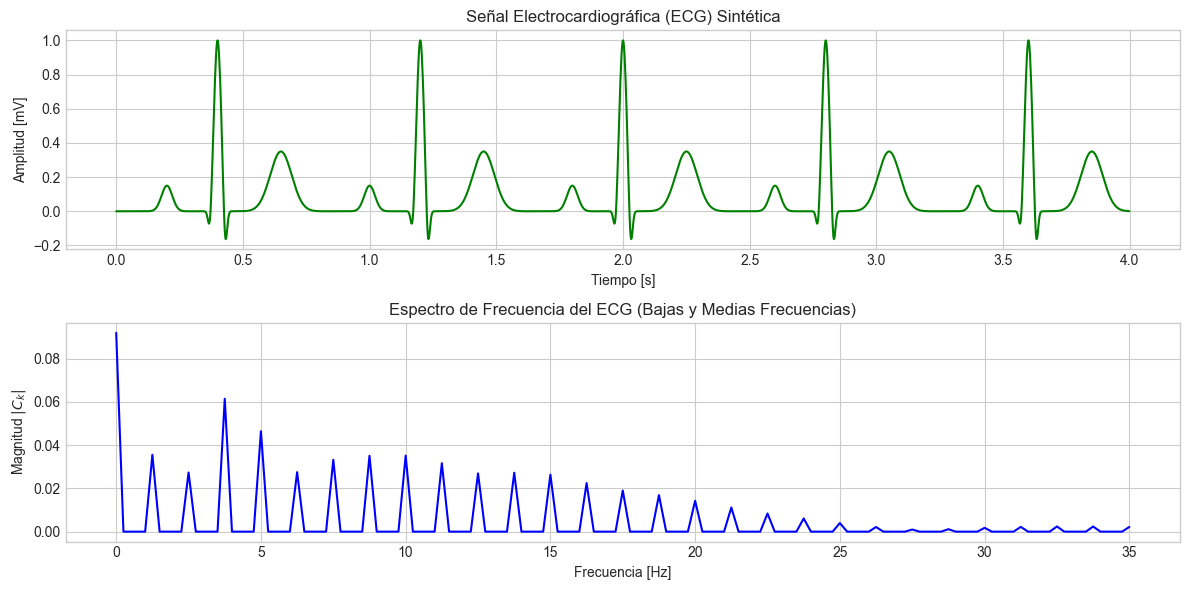

In [9]:
def generar_ecg_sintetico(t, hr=60):
    """
    Genera un ciclo cuasi-periódico de ECG sintético combinando gaussianas.
    """
    f_cardiac = hr / 60.0
    t_mod = np.mod(t, 1.0 / f_cardiac)
    
    # Ondas representadas como sumas de gaussianas
    p_wave = 0.15 * np.exp(-((t_mod - 0.2) / 0.03)**2)
    q_wave = -0.15 * np.exp(-((t_mod - 0.37) / 0.01)**2)
    qrs_wave = 1.0 * np.exp(-((t_mod - 0.40) / 0.02)**2)
    s_wave = -0.25 * np.exp(-((t_mod - 0.43) / 0.01)**2)
    t_wave = 0.35 * np.exp(-((t_mod - 0.65) / 0.06)**2)
    
    return p_wave + q_wave + qrs_wave + s_wave + t_wave

# Crear señal ECG sintética limpia
fs_ecg = 500  # Frecuencia de muestreo 500 Hz
t_ecg = np.linspace(0, 4, 4 * fs_ecg, endpoint=False)
x_ecg = generar_ecg_sintetico(t_ecg, hr=75)

# Coeficientes de Fourier y frecuencias
N_ecg = len(x_ecg)
X_ecg = np.abs(np.fft.fftshift(np.fft.fft(x_ecg) / N_ecg))
freqs_ecg = np.fft.fftshift(np.fft.fftfreq(N_ecg, d=1/fs_ecg))

# Graficar ECG en tiempo y su espectro de frecuencia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(t_ecg, x_ecg, 'g-', linewidth=1.5)
ax1.set_title('Señal Electrocardiográfica (ECG) Sintética')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [mV]')
ax1.grid(True)

# Mostrar solo frecuencias positivas hasta 35 Hz
mask_ecg = (freqs_ecg >= 0) & (freqs_ecg <= 35)
ax2.plot(freqs_ecg[mask_ecg], X_ecg[mask_ecg], 'b-', linewidth=1.5)
ax2.set_title('Espectro de Frecuencia del ECG (Bajas y Medias Frecuencias)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud $|C_k|$')
ax2.grid(True)

plt.tight_layout()
plt.show()

La señal electrocardiográfica se compone de ondas asociadas a la despolarización y repolarización del tejido cardíaco, distribuidas en el dominio de la frecuencia de la siguiente forma:   

Onda P (Despolarización Auricular): Corresponde a deflexiones lentas y suaves. Sus componentes principales de frecuencia se ubican en el rango de $0.5 \text{ Hz} \text{ a } 10 \text{ Hz}$.   

Complejo QRS (Despolarización Ventricular): Corresponde al cambio de voltaje más rápido y abrupto en el tiempo. Al tener pendientes muy pronunciadas, requiere componentes espectrales de alta frecuencia, concentrando su energía entre $8 \text{ Hz} \text{ y } 40 \text{ Hz}$ (con un pico central alrededor de $10 \text{ Hz} - 15 \text{ Hz}$).   

Onda T (Repolarización Ventricular): Representa una variación lenta de voltaje al final del ciclo cardíaco. Sus frecuencias son muy bajas, situándose típicamente entre $0.5 \text{ Hz} \text{ y } 7 \text{ Hz}$.  